# Weather Temperature Analysis of several Argentina's Cities in 2023. 

## Objetive

We will try to explain how was the Argentina's Temperatures in differents cities, and we try to extract insights lookign at several charts of our dataset

# Import Libraries

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load Dataset

In [5]:
df = pd.read_csv('data/temperature_data_arg_2023.csv')
df.head()

,Fecha,Ciudad,Temperatura Maxima,Temperatura Minima,Precipitacion,Velocidad del Viento,Humedad Relativa
0,1/1/2023,Buenos Aires,27,18,0.0,22.7,68.8
1,1/1/2023,Cordoba,35,18,0.0,33.8,61.7
2,1/1/2023,Rosario,23,21,0.0,10.6,80.0
3,1/1/2023,Mendoza,35,21,0.0,23.8,76.8
4,1/1/2023,Tucuman,36,18,17.2,25.7,54.9


# Data Exploration

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Fecha                 1825 non-null   object 
 1   Ciudad                1825 non-null   object 
 2   Temperatura Maxima    1825 non-null   int64  
 3   Temperatura Minima    1825 non-null   int64  
 4   Precipitacion         1825 non-null   float64
 5   Velocidad del Viento  1825 non-null   float64
 6   Humedad Relativa      1825 non-null   float64
dtypes: float64(3), int64(2), object(2)
memory usage: 99.9+ KB


In [7]:
df.describe()

,Temperatura Maxima,Temperatura Minima,Precipitacion,Velocidad del Viento,Humedad Relativa
count,1825.000000,1825.000000,1825.000000,1825.000000,1825.000000
mean,17.827945,10.191233,11.469205,24.963945,59.251890
std,8.139477,6.540120,27.714274,8.640341,17.282792
min,2.000000,-3.000000,0.000000,10.000000,30.000000
25%,12.000000,6.000000,0.000000,17.900000,44.400000
50%,17.000000,10.000000,0.000000,24.900000,58.200000
75%,23.000000,15.000000,0.000000,32.300000,74.800000
max,36.000000,22.000000,119.500000,40.000000,90.000000


In [ ]:
# We converted the Fecha Colunm since this is not a datetime data

df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')
df = df.sort_values('Fecha')
df.head()

,Fecha,Ciudad,Temperatura Maxima,Temperatura Minima,Precipitacion,Velocidad del Viento,Humedad Relativa
0,2023-01-01,Buenos Aires,27,18,0.0,22.7,68.8
1,2023-01-01,Cordoba,35,18,0.0,33.8,61.7
2,2023-01-01,Rosario,23,21,0.0,10.6,80.0
3,2023-01-01,Mendoza,35,21,0.0,23.8,76.8
4,2023-01-01,Tucuman,36,18,17.2,25.7,54.9


# AVG Max Temperature Analysis

In [10]:
avg_temp = df.groupby('Ciudad')['Temperatura Maxima'].mean()

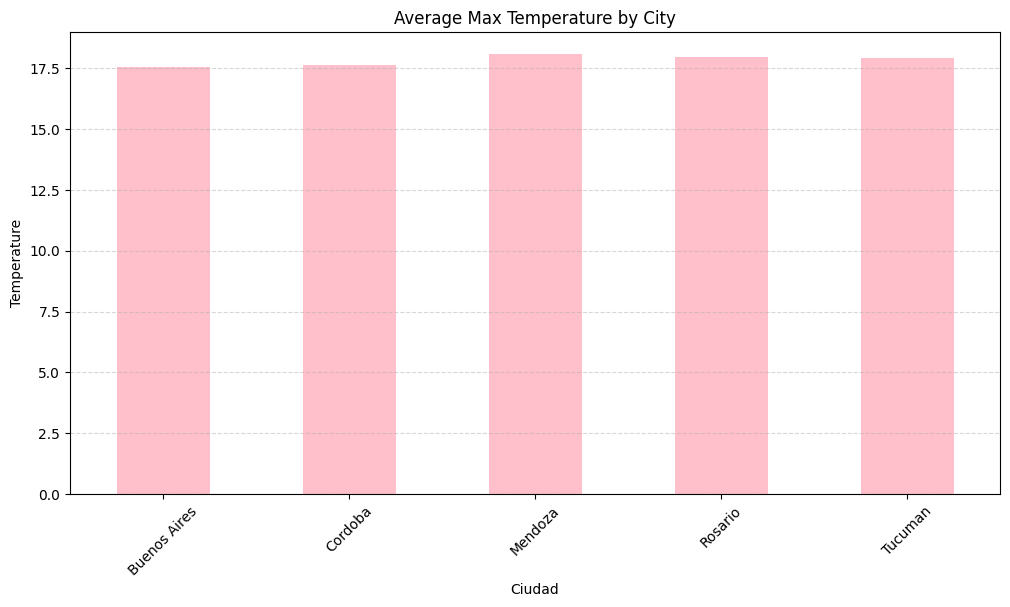

In [109]:
plt.figure(figsize=(12, 6))
avg_temp.plot(kind='bar', rot=45, color='pink')
plt.title('Average Max Temperature by City')
plt.ylabel('Temperature')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# AVG Min Temperature Analysis

In [26]:
avg_temp_min = df.groupby('Ciudad')["Temperatura Minima"].mean()

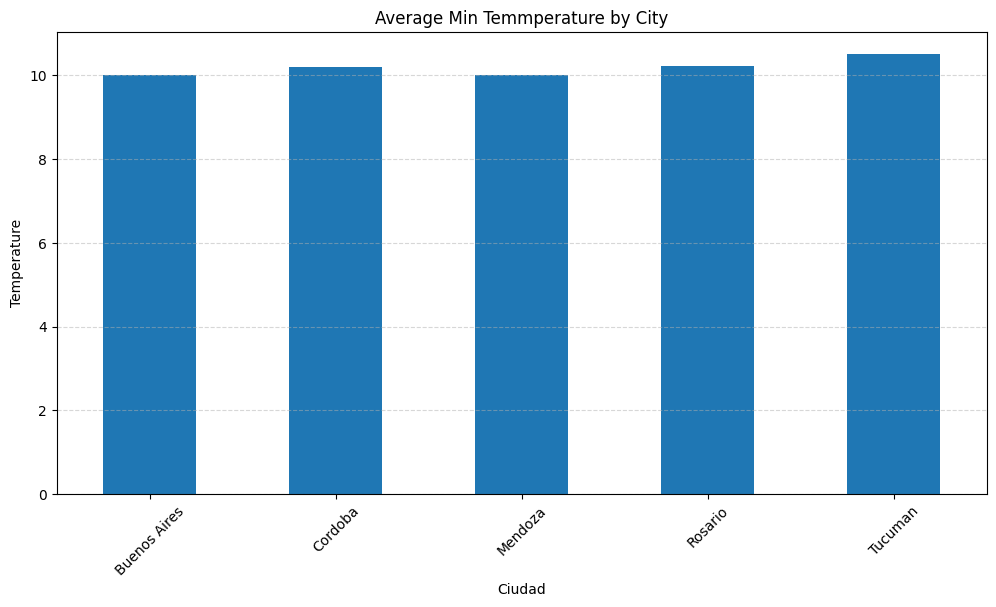

In [94]:
plt.figure(figsize=(12, 6))
avg_temp_min.plot(kind='bar', rot=45)
plt.title('Average Min Temmperature by City')
plt.ylabel('Temperature')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Monthly Temperature Analysis

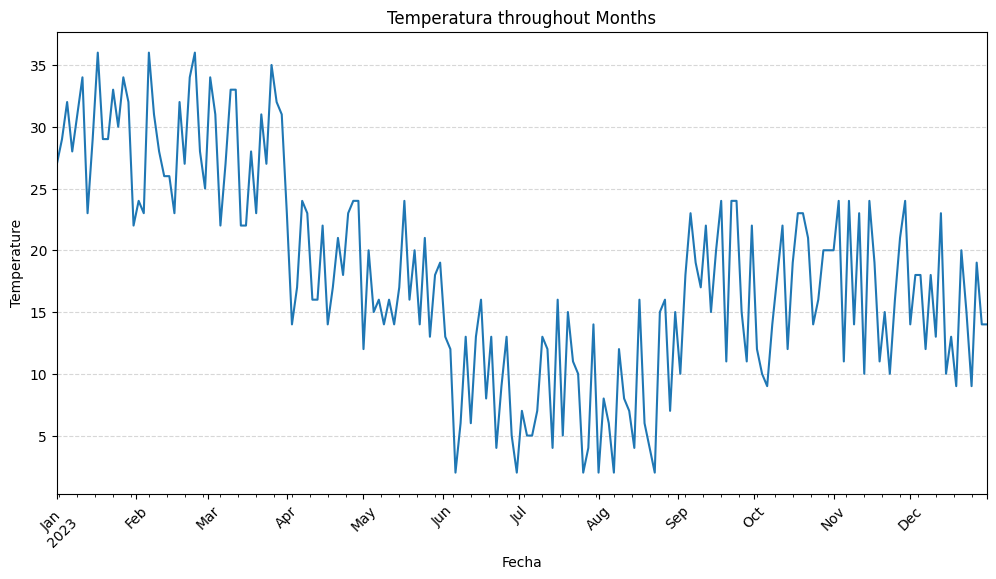

In [95]:
df_temp = df.set_index('Fecha')
df_sample = df_temp[::10]

plt.figure(figsize=(12, 6))
df_sample['Temperatura Maxima'].plot(kind='line')
plt.title('Temperatura throughout Months')
plt.ylabel('Temperature')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Monthly Temperature Analysis by City

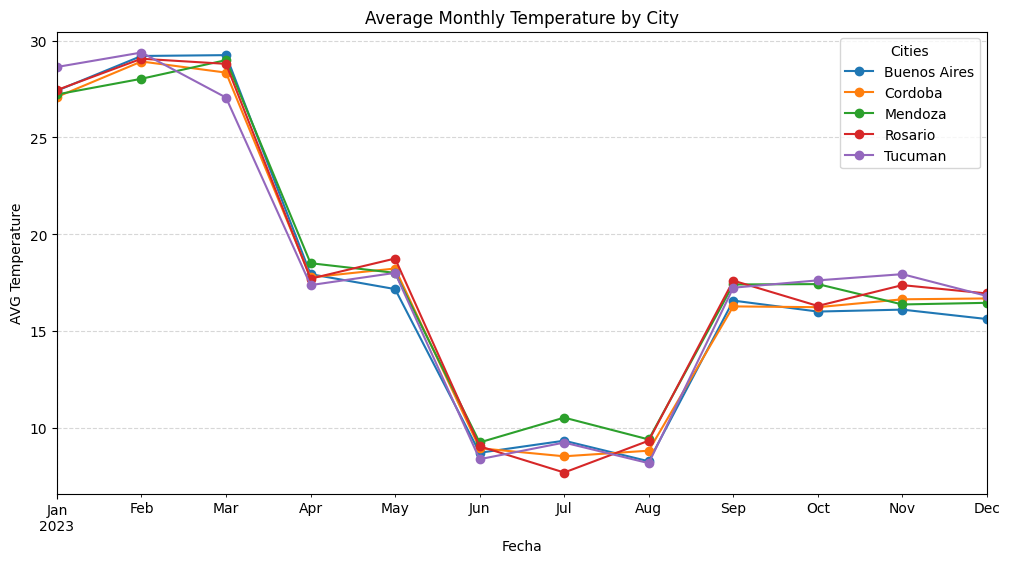

In [ ]:
df_cities = df_temp.groupby('Ciudad')['Temperatura Maxima'].resample('MS').mean().unstack(level=0)
df_cities.plot(kind='line', figsize=(12, 6), marker='o')
plt.title('Average Monthly Temperature by City')
plt.ylabel('AVG Temperature')
plt.legend(title='Cities', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# SUM Precipitation Analysis

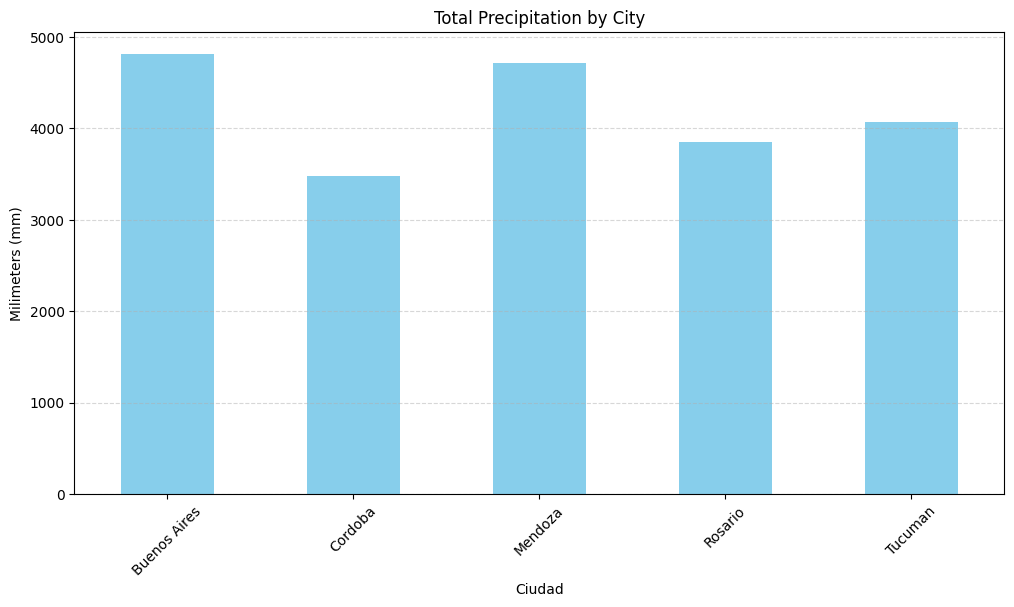

In [105]:
df_total_precipitation = df_temp.groupby('Ciudad')['Precipitacion'].sum()

plt.figure(figsize=(12, 6))
df_total_precipitation.plot(kind='bar', rot=45, color='skyblue')
plt.title('Total Precipitation by City')
plt.ylabel('Milimeters (mm)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# SUM Precipitation Analysis by City

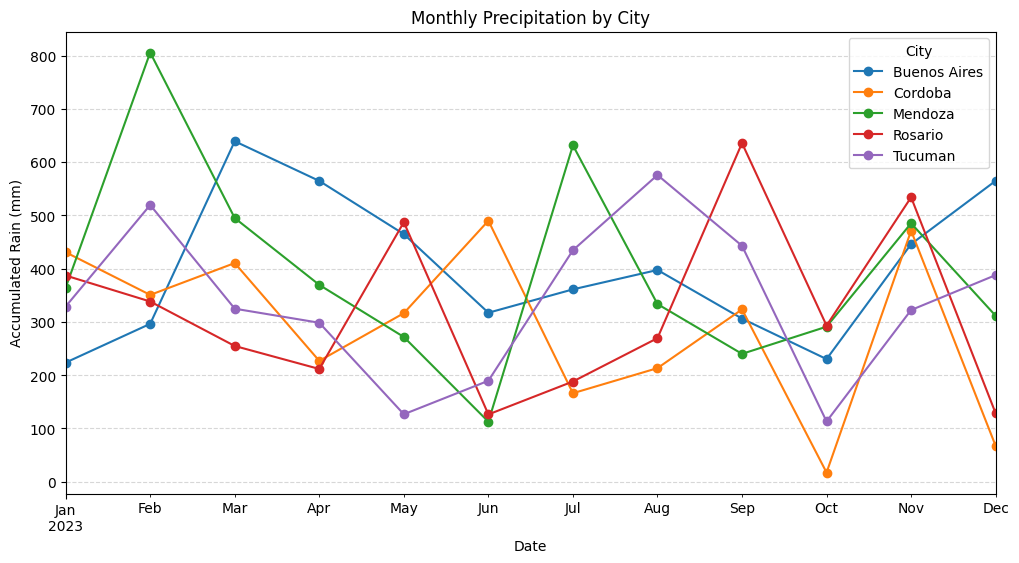

In [104]:
df_monthly_precipitation = df_temp.groupby('Ciudad')['Precipitacion'].resample('MS').sum().unstack(level=0)

df_monthly_precipitation.plot(kind='line', marker='o', figsize=(12,6))
plt.title('Monthly Precipitation by City')
plt.xlabel('Date')
plt.ylabel('Accumulated Rain (mm)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='City')
plt.show()

# Precipitation vs Temperature in Buenos Aires city

In [117]:
df_pre_ba = df_temp[df_temp['Ciudad'] == 'Buenos Aires']
df_pre_ba = df_pre_ba['Precipitacion'].resample('MS').sum()

df_temp_ba = df_temp[df_temp['Ciudad'] == 'Buenos Aires']
df_temp_ba = df_temp_ba['Temperatura Maxima'].resample('MS').mean()


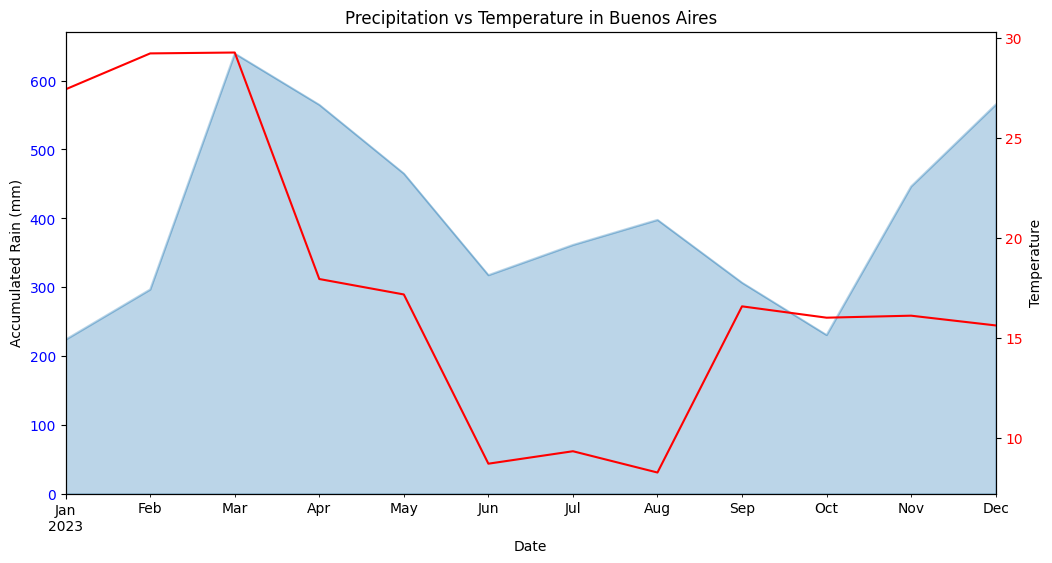

In [136]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

df_pre_ba.plot(kind='area', ax= ax1, alpha=0.3)
df_temp_ba.plot(kind='line', ax=ax2, color='red')
ax1.set_ylabel('Accumulated Rain (mm)')
ax2.set_ylabel('Temperature')
ax1.set_xlabel('Date')
ax1.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')
plt.title('Precipitation vs Temperature in Buenos Aires')
plt.show()

# Precipitation vs Temperature in Cordoba, Rosario, Mendoza and Tucuman

In [176]:
df_pre_temp_cor = df_temp[df_temp['Ciudad'] == 'Cordoba']
sum_pre_cor = df_pre_temp_cor['Precipitacion'].resample('MS').sum()
avg_tem_cor = df_pre_temp_cor['Temperatura Maxima'].resample('MS').mean()

df_pre_temp_ros = df_temp[df_temp['Ciudad'] == 'Rosario']
sum_pre_ros = df_pre_temp_ros['Precipitacion'].resample('MS').sum()
avg_tem_ros = df_pre_temp_ros['Temperatura Maxima'].resample('MS').mean()

df_pre_temp_men = df_temp[df_temp['Ciudad'] == 'Mendoza']
sum_pre_men = df_pre_temp_men['Precipitacion'].resample('MS').sum()
avg_tem_men = df_pre_temp_men['Temperatura Maxima'].resample('MS').mean()

df_pre_temp_tuc = df_temp[df_temp['Ciudad'] == 'Tucuman']
sum_pre_tuc = df_pre_temp_tuc['Precipitacion'].resample('MS').sum()
avg_tem_tuc = df_pre_temp_tuc['Temperatura Maxima'].resample('MS').mean()



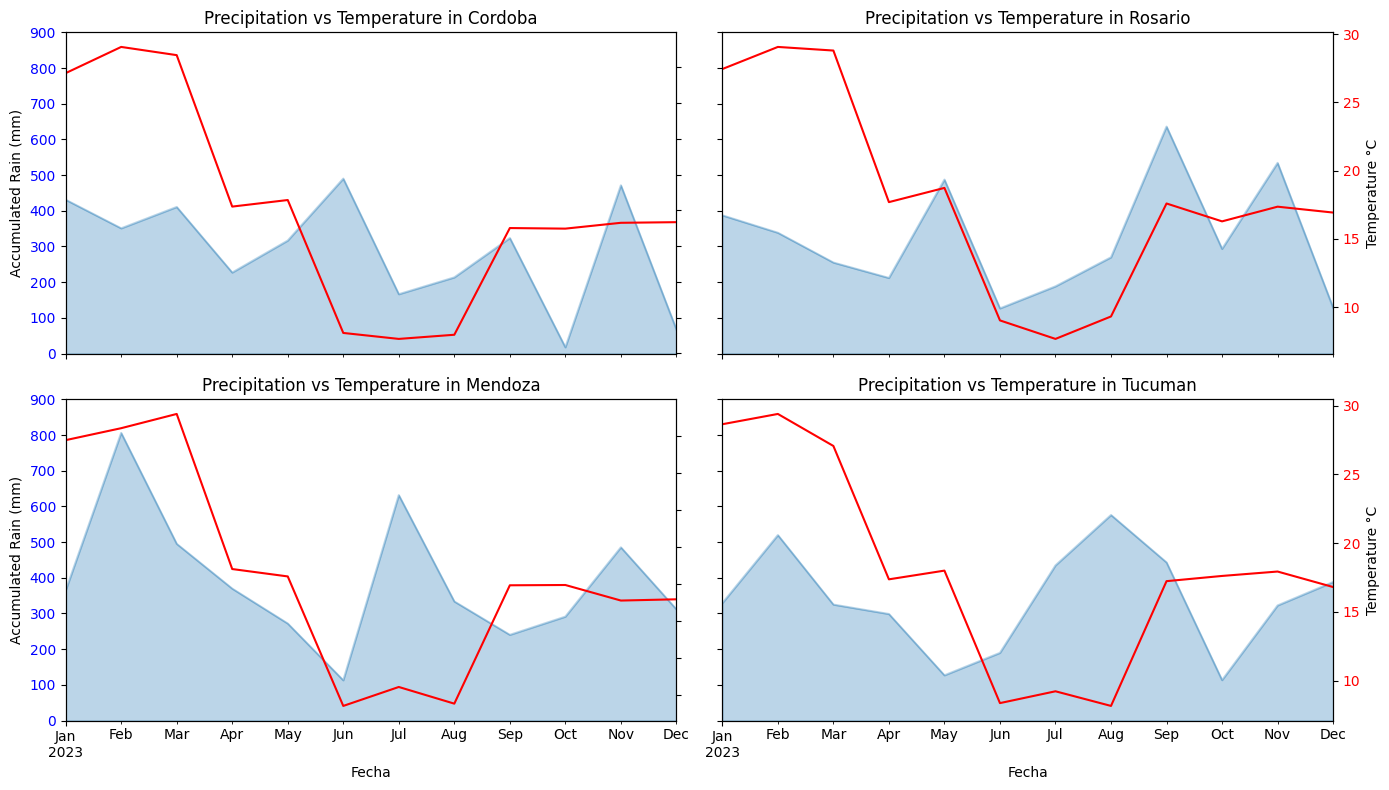

In [ ]:
fig, axs = plt.subplots(2,2, figsize=(14, 8), sharex=True, sharey=True)

ax_pre_1 = axs[0,0]
ax_temp_1 = ax_pre_1.twinx()

ax_pre_2 = axs[0,1]
ax_temp_2 = ax_pre_2.twinx()

ax_pre_3 = axs[1,0]
ax_temp_3 = ax_pre_3.twinx()

ax_pre_4 = axs[1,1]
ax_temp_4 = ax_pre_4.twinx()

sum_pre_cor.plot(kind='area', ax=ax_pre_1, alpha=0.3)
avg_tem_cor.plot(kind='line', ax=ax_temp_1, color='red')

sum_pre_ros.plot(kind='area', ax=ax_pre_2, alpha=0.3)
avg_tem_ros.plot(kind='line', ax=ax_temp_2, color='red')

sum_pre_men.plot(kind='area', ax=ax_pre_3, alpha=0.3)
avg_tem_men.plot(kind='line', ax=ax_temp_3, color='red')

sum_pre_tuc.plot(kind='area', ax=ax_pre_4, alpha=0.3)
avg_tem_tuc.plot(kind='line', ax=ax_temp_4, color='red')

ax_pre_1.set_title('Precipitation vs Temperature in Cordoba')
ax_pre_2.set_title('Precipitation vs Temperature in Rosario')
ax_pre_3.set_title('Precipitation vs Temperature in Mendoza')
ax_pre_4.set_title('Precipitation vs Temperature in Tucuman')

ax_pre_1.set_ylabel('Accumulated Rain (mm)')
ax_pre_3.set_ylabel('Accumulated Rain (mm)')
ax_temp_2.set_ylabel('Temperature °C')
ax_temp_4.set_ylabel('Temperature °C')
ax_temp_1.set_yticklabels([])
ax_temp_3.set_yticklabels([])

ax_pre_1.set_ylim(0,900)
ax_pre_2.set_ylim(0,900)
ax_pre_3.set_ylim(0,900)
ax_pre_4.set_ylim(0,900)

ax_pre_1.tick_params(axis='y', labelcolor = 'blue')
ax_pre_3.tick_params(axis='y', labelcolor = 'blue')
ax_temp_2.tick_params(axis='y', labelcolor = 'red')
ax_temp_4.tick_params(axis='y', labelcolor = 'red')

plt.tight_layout()

plt.show()

# Conclusion

This analysis explored temperature and precipitation patterns across several Argentine cities. The results show clear seasonal trends and differences between regions, particularly highlighting higher average temperatures in Mendoza and lower temperatures in Buenos Aires.

# Insights 

- Mendoza shows the highest average temperatures among the analyzed cities.
- A clear seasonal pattern is observed. Temperatures decrease between June and September, which corresponds to winter in the Southern Hemisphere
- Average temperatures in 2024 appear to be lower than those in 2023 by approximately 10°C in some months. Further analysis would be required to determine the cause of this variation.
- In Buenos Aires, the highest precipitation levels were recorded in March, when temperatures were also relatively high. This suggests that rainfall may be more frequent during the summer months, although some precipitation increases were also observed during winter.
- Córdoba and Rosario: They have very similar behaviors (which makes sense due to their geographical proximity), with significant rainfall in the transition months (autumn/spring).
- Tucumán and Mendoza: In Mendoza, rainfall increases significantly (around 800 mm) during the summer, coinciding with the heat. In contrast, Tucumán experiences little rainfall during the warmer months. A more in-depth analysis is needed to determine the source of this pattern.